In [1]:
import os

GPU_NUM = 0
GPU_NUM = str(GPU_NUM)

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID" 
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_NUM 

# torch를 CUDA_VISIBLE_DEVICES 뒤에 import 해야 제대로 설정됨.
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f'CUDA Device Name: {torch.cuda.get_device_name(0)}, GPU NUM: {GPU_NUM}')
else: print(device)

torch.cuda.empty_cache() 

CUDA Device Name: NVIDIA GeForce RTX 4090, GPU NUM: 0


In [2]:
from dataclasses import dataclass

import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from pathlib import Path

import torch
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

In [3]:
from utils.utils import *
from utils.config import Config

allocate_dummy_gpu_memory(10)

Allocated dummy GPU memory: 10240.00 MiB


In [ ]:
cfg = Config(name='Dataset_Haze_Clutter', data='Data_EchoNet-Dynamic')
print(cfg)

ECHO_DIR = Path(cfg.data_path / cfg.data / 'frames')
SAVE_DIR = Path(cfg.base_path) / cfg.data / 'haze'

----------------------------------------------------------------------
                        Config Details (Auto)                         
----------------------------------------------------------------------

[ Base Settings ]
  name                   : Dataset_Haze_Clutter
  data                   : Data_EchoNet-Dynamic
  mkdir                  : False
  dtype                  : float64
  device                 : cpu
  multi_gpu              : False

[ Paths ]
  base_path              : /ds/mkseo/SM-Dehazing
  data_path              : /ds/mkseo/SM-Dehazing/data
  res_path               : /ds/mkseo/SM-Dehazing/res/Dataset_Haze_Clutter
  fig_path               : /ds/mkseo/SM-Dehazing/res/Dataset_Haze_Clutter/fig
  loss_path              : /ds/mkseo/SM-Dehazing/res/Dataset_Haze_Clutter/loss
  model_path             : /ds/mkseo/SM-Dehazing/res/Dataset_Haze_Clutter/model
----------------------------------------------------------------------


In [5]:
echo_frames = listdir(ECHO_DIR)
_shape      = transforms.ToTensor()(Image.open(ECHO_DIR / echo_frames[0])).shape
print(f'Echocardiogram Shape: {_shape}')

echo_transform  = transforms.Compose([
    transforms.Resize((_shape[1:])),
    transforms.ToTensor()
])

Echocardiogram Shape: torch.Size([3, 112, 112])


In [6]:
import torch
import torch.nn.functional as F


def create_fan_mask(
    img,
    apex=None,
    radius=None,
    angle_min_deg=35,
    angle_max_deg=145,
):
    """
    심초음파 부채꼴 영역 mask 생성.

    img shape:
        [H, W], [B, H, W], or [B, C, H, W]

    반환:
        img와 broadcast 가능한 mask
        내부=1, 외부=0
    """
    H, W = img.shape[-2], img.shape[-1]
    device = img.device
    dtype = img.dtype

    if apex is None:
        # 보통 sector apex는 영상 상단 중앙 근처
        apex_y = 0
        apex_x = W / 2
    else:
        apex_y, apex_x = apex

    if radius is None:
        radius = H * 1.15

    yy, xx = torch.meshgrid(
        torch.arange(H, device=device, dtype=dtype),
        torch.arange(W, device=device, dtype=dtype),
        indexing="ij",
    )

    dy = yy - apex_y
    dx = xx - apex_x

    r = torch.sqrt(dx ** 2 + dy ** 2)

    # 아래 방향을 90도로 보는 좌표계
    angle = torch.atan2(dy, dx) * 180.0 / torch.pi

    radial_mask = r <= radius
    angle_mask = (angle >= angle_min_deg) & (angle <= angle_max_deg)

    mask = (radial_mask & angle_mask).float()

    if img.ndim == 2:
        return mask
    elif img.ndim == 3:
        return mask[None]
    elif img.ndim == 4:
        return mask[None, None]
    else:
        raise ValueError(f"Unsupported shape: {img.shape}")

def threshold_mask(img, threshold=0.03, kernel_size=9):
    mask = (img > threshold).float()

    original_ndim = mask.ndim

    if mask.ndim == 2:
        x = mask[None, None]
    elif mask.ndim == 3:
        x = mask[:, None]
    elif mask.ndim == 4:
        x = mask
    else:
        raise ValueError(mask.shape)

    pad = kernel_size // 2
    x = F.max_pool2d(x, kernel_size=kernel_size, stride=1, padding=pad)

    if original_ndim == 2:
        return x[0, 0]
    elif original_ndim == 3:
        return x[:, 0]
    else:
        return x

In [81]:
import torch
import torch.nn.functional as F


def normalize01(x, eps=1e-8):
    x_min = x.amin(dim=(-2, -1), keepdim=True)
    x_max = x.amax(dim=(-2, -1), keepdim=True)
    return (x - x_min) / (x_max - x_min + eps)


def depth_map_like(x):
    """
    top = 0, bottom = 1
    x shape: [H, W], [B, H, W], or [B, C, H, W]
    """
    H = x.shape[-2]
    d = torch.linspace(0, 1, H, device=x.device, dtype=x.dtype)

    if x.ndim == 2:
        return d[:, None]
    elif x.ndim == 3:
        return d[None, :, None]
    elif x.ndim == 4:
        return d[None, None, :, None]
    else:
        raise ValueError(f"Unsupported shape: {x.shape}")


def gaussian_kernel2d(kernel_y, kernel_x, sigma_y, sigma_x, device, dtype):
    y = torch.arange(kernel_y, device=device, dtype=dtype) - kernel_y // 2
    x = torch.arange(kernel_x, device=device, dtype=dtype) - kernel_x // 2

    yy, xx = torch.meshgrid(y, x, indexing="ij")

    kernel = torch.exp(
        -0.5 * ((yy / sigma_y) ** 2 + (xx / sigma_x) ** 2)
    )
    kernel = kernel / kernel.sum()

    return kernel


def anisotropic_psf_blur(
    img,
    sigma_axial=1.0,
    sigma_lateral=3.0,
    kernel_scale=6,
):
    """
    Ultrasound PSF-like anisotropic blur.

    axial    = height direction
    lateral  = width direction
    """
    original_ndim = img.ndim

    if img.ndim == 2:
        x = img[None, None]
    elif img.ndim == 3:
        x = img[:, None]
    elif img.ndim == 4:
        x = img
    else:
        raise ValueError(f"Unsupported shape: {img.shape}")

    B, C, H, W = x.shape
    device = x.device
    dtype = x.dtype

    ky = max(int(kernel_scale * sigma_axial) | 1, 3)
    kx = max(int(kernel_scale * sigma_lateral) | 1, 3)

    kernel = gaussian_kernel2d(
        ky,
        kx,
        sigma_y=sigma_axial,
        sigma_x=sigma_lateral,
        device=device,
        dtype=dtype,
    )

    kernel = kernel[None, None].repeat(C, 1, 1, 1)

    pad_y = ky // 2
    pad_x = kx // 2

    x_pad = F.pad(x, (pad_x, pad_x, pad_y, pad_y), mode="reflect")
    out = F.conv2d(x_pad, kernel, groups=C)

    if original_ndim == 2:
        return out[0, 0]
    elif original_ndim == 3:
        return out[:, 0]
    else:
        return out


def low_frequency_clutter(
    img,
    strength=1.0,
    sigma_axial=18.0,
    sigma_lateral=28.0,
):
    """
    Smooth low-frequency haze/clutter map.
    """
    noise = torch.randn_like(img)

    clutter = anisotropic_psf_blur(
        noise,
        sigma_axial=sigma_axial,
        sigma_lateral=sigma_lateral,
        kernel_scale=6,
    )

    clutter = normalize01(clutter)

    return strength * clutter


def rayleigh_speckle(img, strength=0.4, eps=1e-8):
    """
    Multiplicative Rayleigh speckle.

    If img = torch.ones_like(original_img),
    this returns a speckle map centered around 1.
    """
    g1 = torch.randn_like(img)
    g2 = torch.randn_like(img)

    r = torch.sqrt(g1 ** 2 + g2 ** 2 + eps)

    r = r / (r.mean(dim=(-2, -1), keepdim=True) + eps)

    speckle = 1.0 + strength * (r - 1.0)
    speckle = torch.clamp(speckle, min=0.05)

    return img * speckle


def log_compress(img, dynamic_range_db=55.0, eps=1e-8):
    """
    B-mode-like log compression.
    Output range: [0, 1]
    """
    img = torch.clamp(img, min=0.0)

    img = img / (img.amax(dim=(-2, -1), keepdim=True) + eps)

    db = 20.0 * torch.log10(img + eps)
    db = torch.clamp(db, min=-dynamic_range_db, max=0.0)

    out = (db + dynamic_range_db) / dynamic_range_db

    return out


def generate_ultrasound_haze(img):
    """
    Generate additive ultrasound-like haze map.
    Output range: [0, 1]
    """
    haze = low_frequency_clutter(
        torch.zeros_like(img),
        strength=1.0,
    )

    d = depth_map_like(img)
    haze = haze * (0.3 + 0.7 * d)

    haze = anisotropic_psf_blur(
        haze,
        sigma_axial=2.0,
        sigma_lateral=5.0,
    )

    haze = normalize01(haze)

    return haze


def apply_ultrasound_haze(
    img,
    speckle_strength=0.4,
    haze_strength=0.3,
    gamma=0.5,
    threshold=0.03,
    kernel_size=3,
):
    """
    부채꼴 mask 내부에만 ultrasound haze 적용.
    mask 밖 검은 배경은 그대로 유지.
    """
    img = img.float()
    img = torch.clamp(img, 0.0, 1.0)

    # mask = create_fan_mask(
    #     img,
    #     apex=apex,
    #     radius=radius,
    #     angle_min_deg=angle_min_deg,
    #     angle_max_deg=angle_max_deg,
    # )
    mask = threshold_mask(img, threshold, kernel_size)

    haze = generate_ultrasound_haze(img)
    haze = haze * (img ** gamma)
    haze = haze * mask

    speckle = rayleigh_speckle(
        torch.ones_like(img),
        strength=speckle_strength,
    )

    # mask 안쪽에만 speckle 적용
    speckle = speckle * mask + (1.0 - mask)

    # hazy = img * speckle + haze_strength * haze
    # hazy = log_compress(hazy, dynamic_range_db=dynamic_range_db)

    # # 최종적으로 mask 밖은 원본 유지
    # out = img * (1.0 - mask) + hazy * mask
    # out = torch.clamp(out, 0.0, 1.0)
    hazy = img * speckle + haze_strength * haze

    # log_compress 제거
    # hazy = log_compress(hazy)

    out = img * (1.0 - mask) + hazy * mask
    out = torch.clamp(out, 0.0, 1.0)

    return out, haze, speckle, mask

In [82]:
def tensor_to_uint8_img(x):
    return (x.permute(1, 2, 0).detach().cpu().numpy() * 255).astype(np.uint8)

In [83]:
t_img = Image.open(ECHO_DIR / echo_frames[0]).convert('RGB')
t_img = echo_transform(t_img).to(device=device, non_blocking=True)
t_out, t_haze, speckle, mask = apply_ultrasound_haze(
    t_img,
    speckle_strength=0.2,
    haze_strength=0.2,
    gamma=0.1,
    threshold=0.02,
    kernel_size=5
)

torch.Size([3, 112, 112]) torch.Size([3, 112, 112]) torch.Size([3, 112, 112])


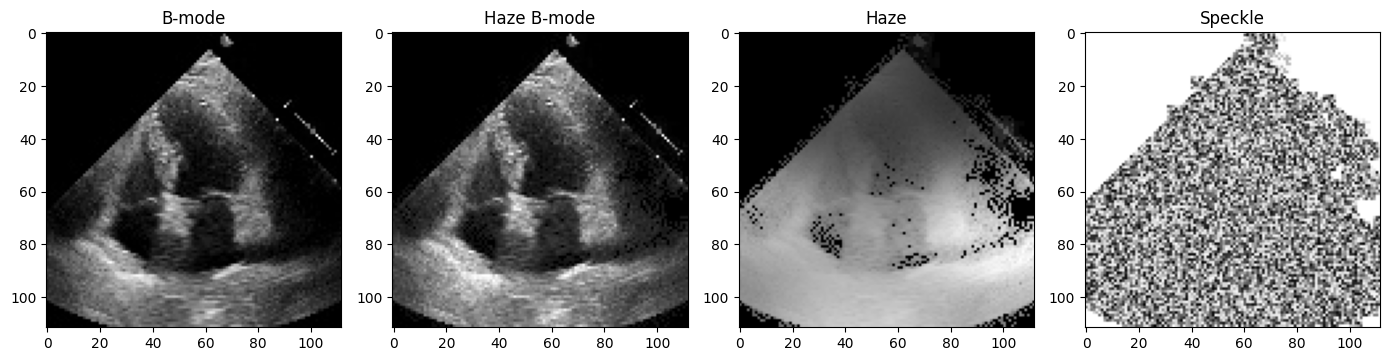

In [84]:
print(t_out.shape, t_haze.shape, speckle.shape)
t_img = tensor_to_uint8_img(t_img)
t_out = tensor_to_uint8_img(t_out)
t_haze = tensor_to_uint8_img(t_haze)
speckle = tensor_to_uint8_img(speckle)

t_img = cv2.cvtColor(t_img, cv2.COLOR_RGB2GRAY)
t_out = cv2.cvtColor(t_out, cv2.COLOR_RGB2GRAY)
t_haze = cv2.cvtColor(t_haze, cv2.COLOR_RGB2GRAY)
speckle = cv2.cvtColor(speckle, cv2.COLOR_RGB2GRAY)
imgs = [t_img, t_out, t_haze, speckle]
titles = ['B-mode', 'Haze B-mode', 'Haze', 'Speckle']

plt.figure(figsize=(14, 7))
for i, img in enumerate(imgs):
    plt.subplot(1, len(imgs), i+1)
    plt.imshow(img, cmap='gray')
    plt.title(titles[i])

plt.tight_layout()
plt.show()

In [70]:
mk_dir(SAVE_DIR)

for i, echo in enumerate(echo_frames):
    name = echo.split('.')[0]
    img = Image.open(ECHO_DIR / echo).convert('RGB')
    img = echo_transform(img).to(device=device, non_blocking=True)

    out, haze, speckle, mask = apply_ultrasound_haze(
    img,
    speckle_strength=0.2,
    haze_strength=0.2,
    gamma=0.1,
    threshold=0.02,
    kernel_size=5
    )

    out = tensor_to_uint8_img(out)
    out = cv2.cvtColor(out, cv2.COLOR_RGB2GRAY)

    save_path = SAVE_DIR / f'{name}.png'

    out = Image.fromarray(out)
    out.save(str(save_path), dpi=(500, 500))

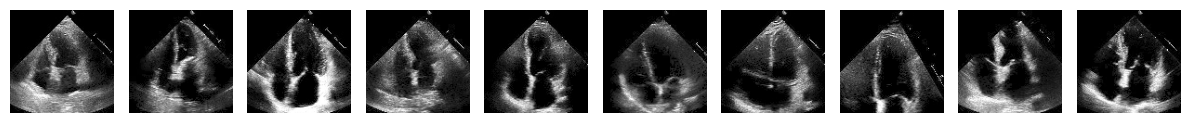

In [85]:
results = listdir(SAVE_DIR)
imgs = [Image.open(SAVE_DIR / results[i]) for i in range(0, 100, 10)]

plt.figure(figsize=(12, 5))
for i, img in enumerate(imgs):
    plt.subplot(1, len(imgs), i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()